# Phase 4: Model Evaluation
**MIS 637 B — Group 7**  
Confusion matrices, ROC curves, full comparison table

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')

X = np.load('../data/X_scaled.npy')
y = np.load('../data/y.npy')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

with open('../outputs/models/all_models.pkl', 'rb') as f:
    models = pickle.load(f)

## 1. Confusion Matrices

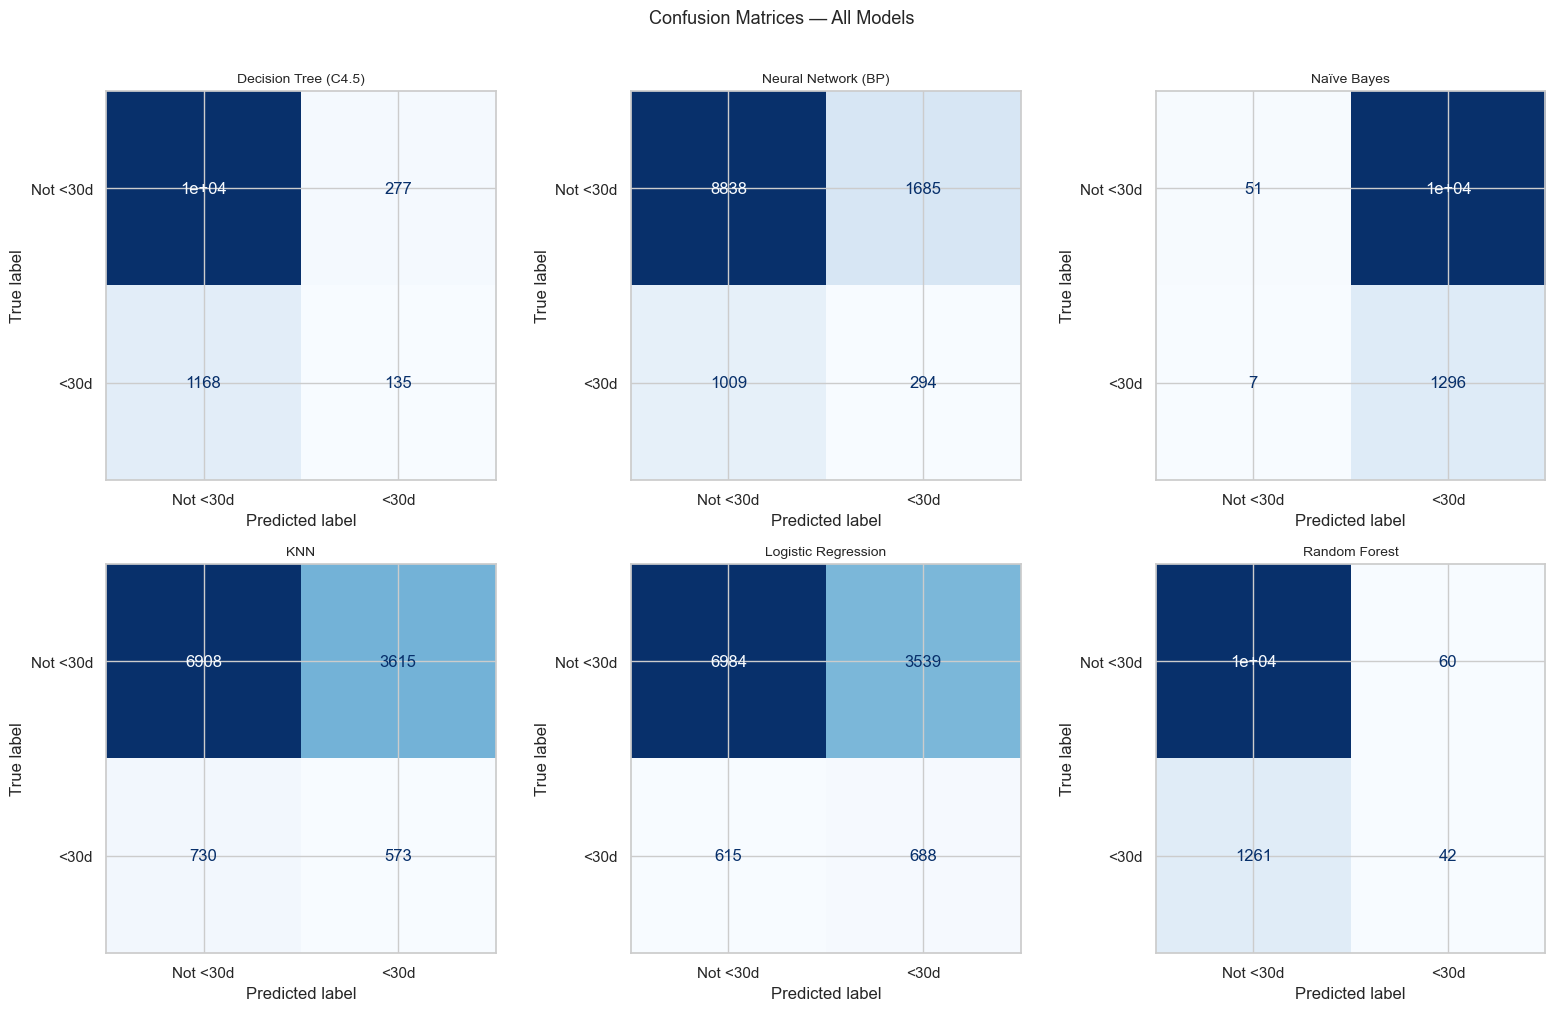

In [2]:
n = len(models)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not <30d', '<30d'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. ROC Curves

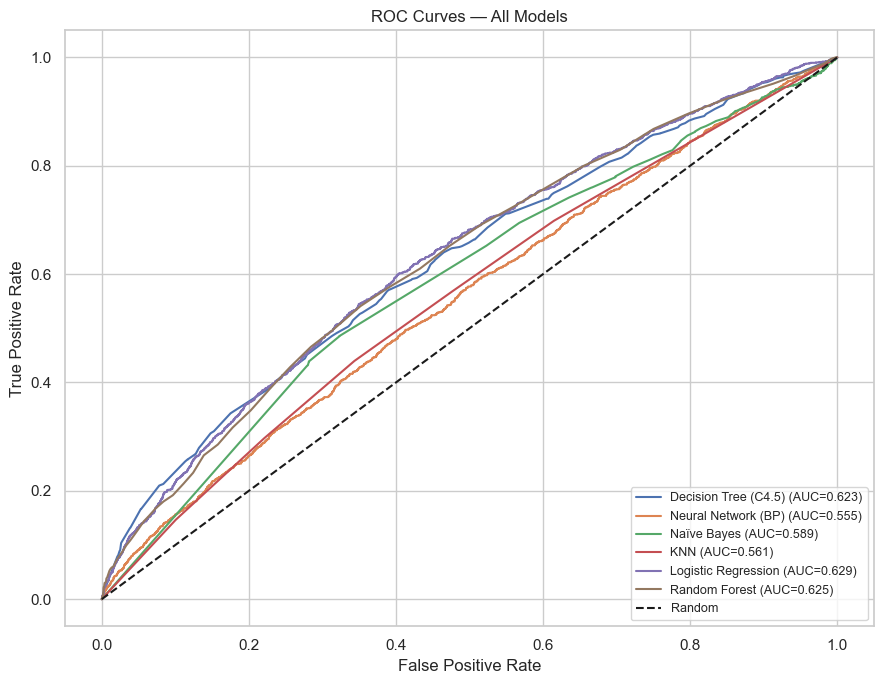

In [3]:
plt.figure(figsize=(9, 7))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves.png', dpi=150)
plt.show()

## 3. Metric Comparison Bar Chart

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Decision Tree (C4.5),0.8778,0.3277,0.1036,0.1574,0.6233
Neural Network (BP),0.7722,0.1486,0.2256,0.1792,0.5552
Naïve Bayes,0.1139,0.1101,0.9946,0.1983,0.5886
KNN,0.6326,0.1368,0.4398,0.2087,0.5609
Logistic Regression,0.6487,0.1628,0.5280,0.2488,0.6290
Random Forest,0.8883,0.4118,0.0322,0.0598,0.6250


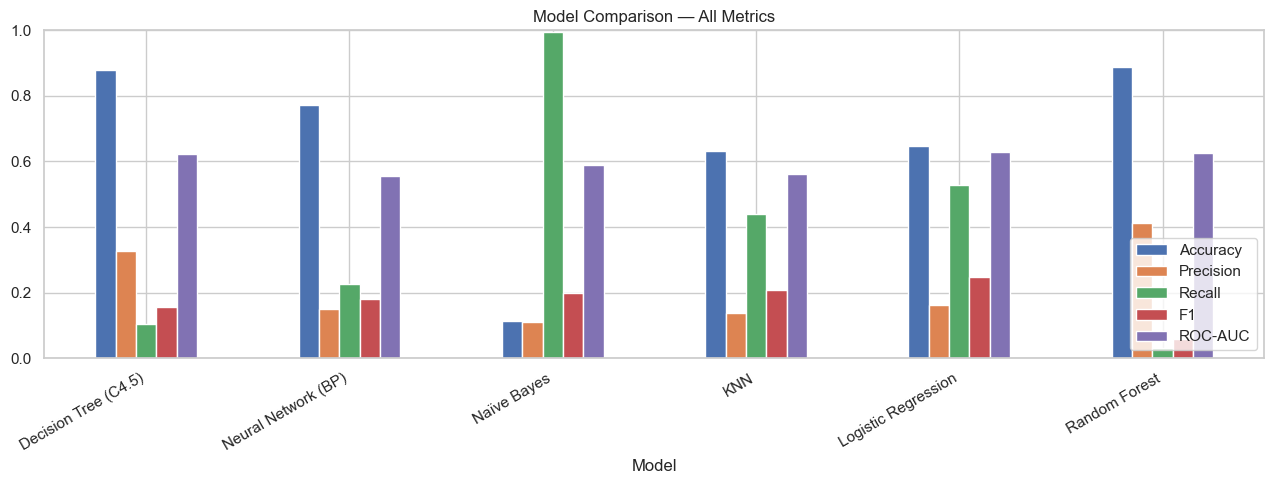

In [4]:
results_df = pd.read_csv('../outputs/model_comparison.csv', index_col='Model')
display(results_df)

results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(13, 5), ylim=(0, 1)
)
plt.title('Model Comparison — All Metrics')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison_bar.png', dpi=150)
plt.show()

## 4. Key Findings

- **False Negatives most costly** — missing a high-risk patient = no intervention
- Prioritize **Recall** and **F1** over raw Accuracy
- Best model: (fill in after running)
- Cluster analysis from Phase 2 revealed patient risk segments (fill in)
